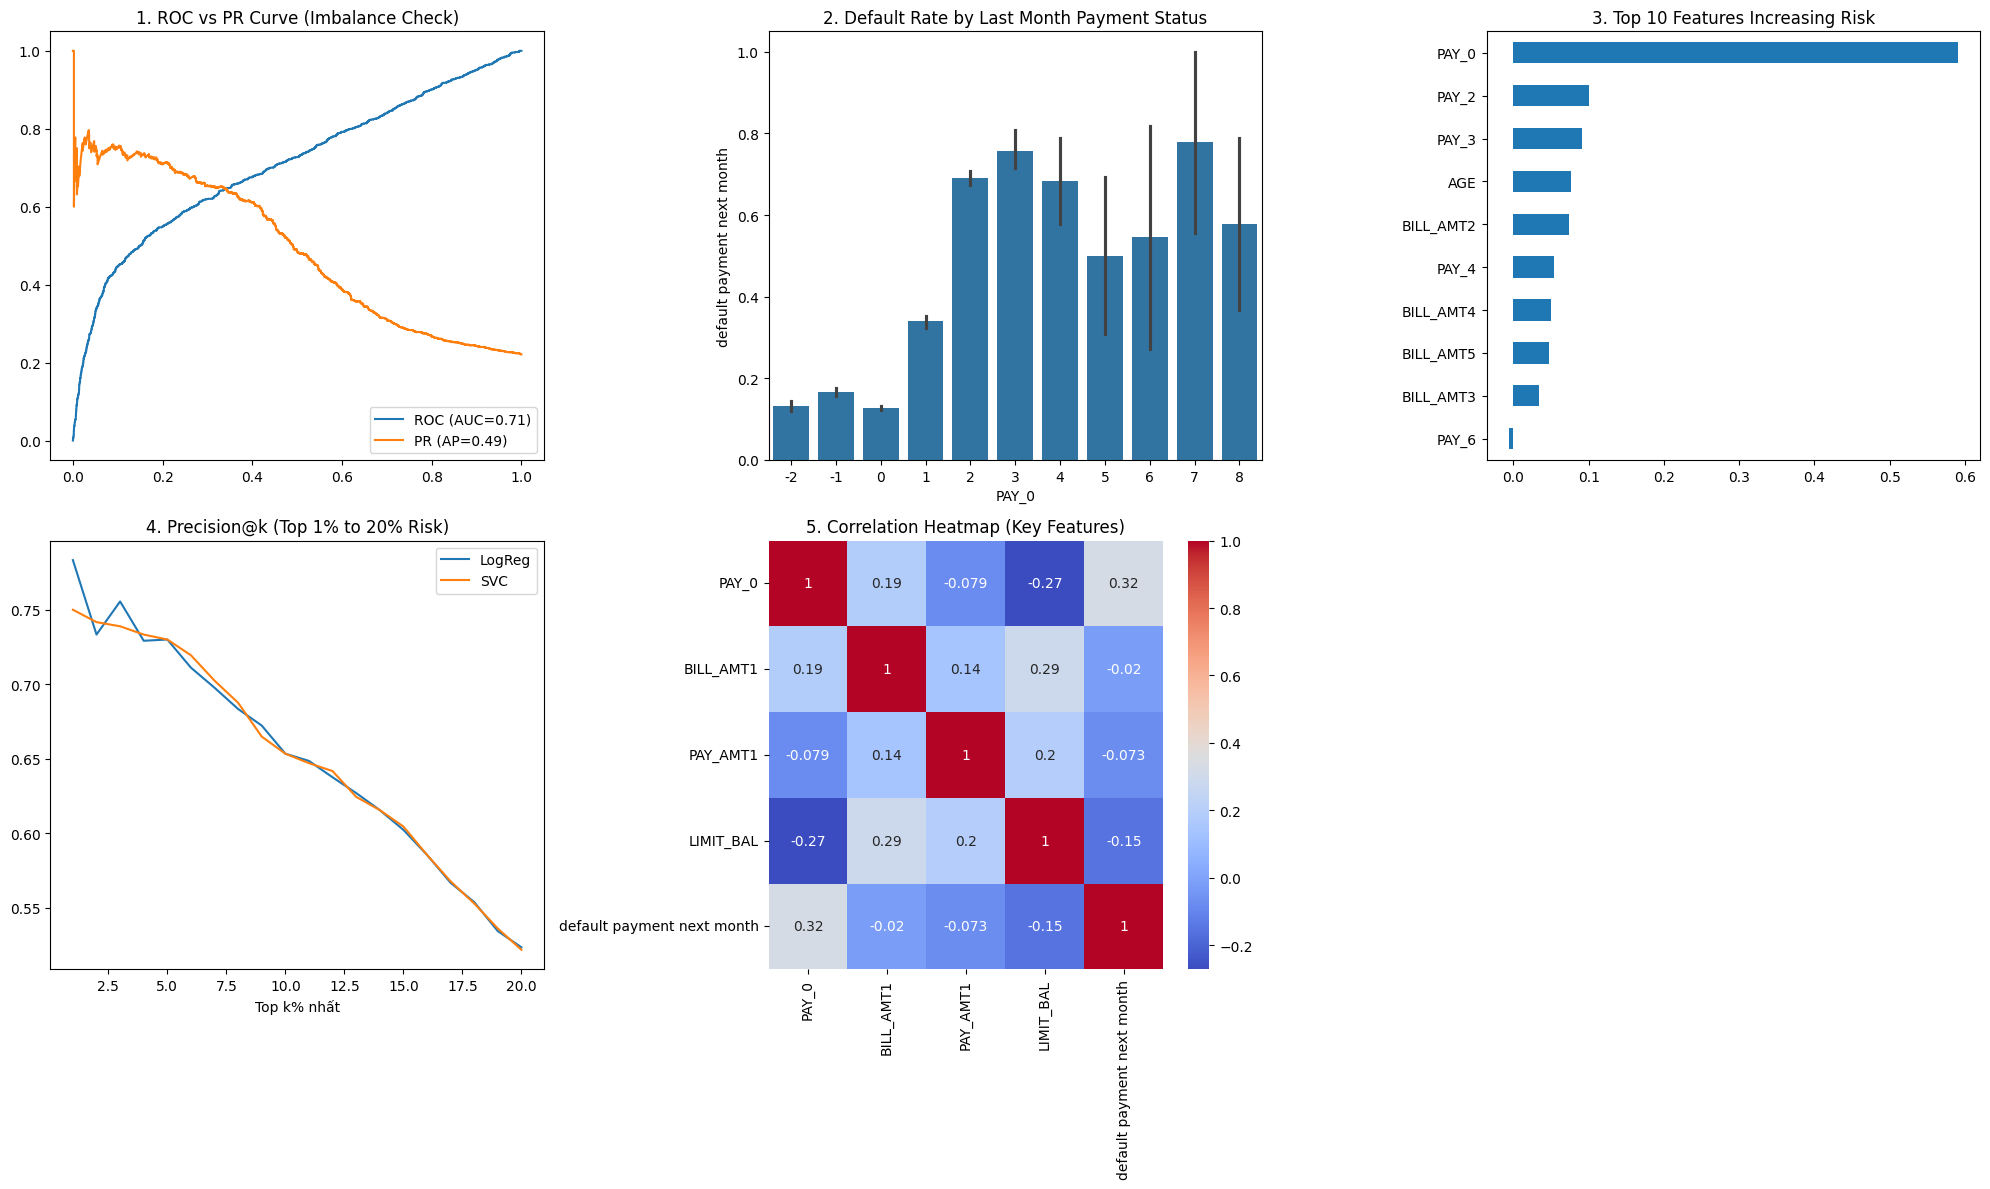

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Tải dữ liệu trực tiếp từ UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)

# 2. Làm sạch dữ liệu (như đã thảo luận)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
X = df.drop(['ID', 'default payment next month'], axis=1)
y = df['default payment next month']

# Chia train/test và chuẩn hóa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Huấn luyện 2 mô hình để lấy dữ liệu vẽ biểu đồ
log_reg = LogisticRegression(class_weight='balanced').fit(X_train_sc, y_train)
svc = LinearSVC(class_weight='balanced', max_iter=10000).fit(X_train_sc, y_train)

# Lấy điểm dự báo (Scores)
y_score_log = log_reg.predict_proba(X_test_sc)[:, 1]
y_score_svc = svc.decision_function(X_test_sc)

# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(20, 12))

# Biểu đồ 1: So sánh ROC và PR Curve (Cho RQ1)
plt.subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(y_test, y_score_log)
precision, recall, _ = precision_recall_curve(y_test, y_score_log)
plt.plot(fpr, tpr, label=f'ROC (AUC={auc(fpr, tpr):.2f})')
plt.plot(recall, precision, label=f'PR (AP={average_precision_score(y_test, y_score_log):.2f})')
plt.title('1. ROC vs PR Curve (Imbalance Check)')
plt.legend()

# Biểu đồ 2: Default Rate theo PAY_0 (Business Insight)
plt.subplot(2, 3, 2)
sns.barplot(x='PAY_0', y='default payment next month', data=df)
plt.title('2. Default Rate by Last Month Payment Status')

# Biểu đồ 3: Feature Importance (Cho Chatbot/Explain)
plt.subplot(2, 3, 3)
coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
coefs.tail(10).plot(kind='barh')
plt.title('3. Top 10 Features Increasing Risk')

# Biểu đồ 4: Precision@k (Cho RQ3 - Top Risk)
plt.subplot(2, 3, 4)
def plot_precision_at_k(y_true, y_score, label):
    df_temp = pd.DataFrame({'true': y_true, 'score': y_score}).sort_values('score', ascending=False)
    k_range = np.arange(1, 21) # xem top 1% đến 20%
    p_at_k = [df_temp.iloc[:int(len(df_temp)*k/100)]['true'].mean() for k in k_range]
    plt.plot(k_range, p_at_k, label=label)

plot_precision_at_k(y_test, y_score_log, 'LogReg')
plot_precision_at_k(y_test, y_score_svc, 'SVC')
plt.title('4. Precision@k (Top 1% to 20% Risk)')
plt.xlabel('Top k% nhất')
plt.legend()

# Biểu đồ 5: Correlation Heatmap (Selected Features)
plt.subplot(2, 3, 5)
sns.heatmap(df[['PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'LIMIT_BAL', 'default payment next month']].corr(), annot=True, cmap='coolwarm')
plt.title('5. Correlation Heatmap (Key Features)')

plt.tight_layout()
plt.show()